In [30]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, random_split

### Define data transformations

In [2]:
transform = transforms.ToTensor()

### Load data

In [ ]:
train_set = datasets.MNIST(
    root = "../datasets",
    train = True,
    download=True,
    transform=transform
)

test_set = datasets.MNIST(
    root="../datasets",
    train=False,
    download=True,
    transform=transform
)

100.0%
100.0%
100.0%
100.0%
100.0%
100.0%
100.0%
100.0%


In [4]:
print("Train set length", len(train_set))
print("Test set length", len(test_set))

Train set length 60000
Test set length 10000


In [5]:
image, label = train_set[0]
print("image shape", image.shape)
print("label", label)

image shape torch.Size([1, 28, 28])
label 5


### Lets visualise one image

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

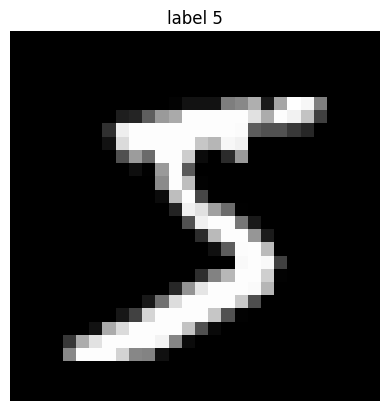

In [9]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"label {label}",)
plt.axis("off")

### Lets check class distribution

In [17]:
labels = [train_set[i][1] for i in range(len(train_set))]

[0 1 2 3 4 5 6 7 8 9]
[5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]


Text(0.5, 1.0, 'Class Distribtion')

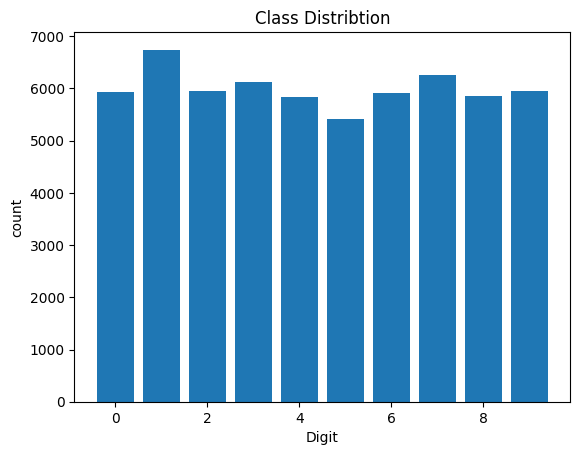

In [26]:
values, counts = np.unique(labels, return_counts=True)
print(values)
print(counts)

plt.bar(values, counts)
plt.xlabel("Digit")
plt.ylabel("count")
plt.title("Class Distribtion")

our classes are almost the same heigh, we can safely say our dataset is safely balanced

### Flattern one image, explaining the concept 

In [27]:
image_flattern = image.view(-1)

print("original shape", image.shape)
print("new shape", image_flattern.shape)

original shape torch.Size([1, 28, 28])
new shape torch.Size([784])


In [ ]:
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

### We need to split data into training and validation data

In [31]:
train_size = int(0.8 * len(train_set))
val_size = len(train_set) - train_size

train_set, val_set = random_split(train_set, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False)

print("train dataset size", len(train_set))
print("validation data size", len(val_set))

train dataset size 48000
validation data size 12000
